<a href="https://colab.research.google.com/github/mteoraso/Electricity_Sector_COL_XM/blob/EDA/demanda_no_atendida.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pydataxm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 99.7 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
cudf-cu12 25.6.0 requires pandas<2.2.4dev0,>=2.0, but you have pandas 2.3.3 which is incompatible.
dask-cudf-cu12 25.6.0 requires pandas<2.2.4dev0,>=2.0, but you have pandas 2.3.3 which is incompatible.


In [2]:
import seaborn as sns
sns.set_theme(style="whitegrid", palette="bright")
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
## Autocorrelacion en series de tiempo
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

In [3]:
# Importación de API XM
from pydataxm.pydatasimem import ReadSIMEM, CatalogSIMEM
# Crear una instancia de ReadSIMEM
# Esta base de datos es sobre fallas en subestaciones de energia
dataset_id = '3C77AF'
fecha_inicio = '2020-01-01'
fecha_fin = '2024-04-30'
generacion = ReadSIMEM(dataset_id, fecha_inicio, fecha_fin)
# Recuperar datos
data = generacion.main(filter=False)
print(data)

****************************************************************************************************
Initializing object
The object has been initialized with the dataset: "Eventos de Demanda No Atendida"
****************************************************************************************************
Inicio consulta sincronica
Creacion url: 0.0026743412017822266
Extraccion de registros: 65.28642773628235
End of data extracting process
****************************************************************************************************
     IdentificadorSuceso      FechaHoraInicio         FechaHoraFin  \
0             S000017905  2020-01-31 13:04:00  2020-01-31 19:59:00   
1             S000017904  2020-01-29 09:43:00  2020-01-29 09:53:00   
2             S000017903  2020-01-27 14:24:00  2020-01-27 16:31:00   
3             S000017901  2020-01-26 07:24:00  2020-01-26 13:15:00   
4             S000017902  2020-01-26 05:16:00  2020-01-26 06:34:00   
...                  ...             

In [4]:
data

,IdentificadorSuceso,FechaHoraInicio,FechaHoraFin,OrigenEvento,EnergiaNoAtendida,DescripcionEvento,CodigoSubAreaOperativa
0,S000017905,2020-01-31 13:04:00,2020-01-31 19:59:00,No programada,151140.0,Demanda no atendida por disparo del activo SAN...,Are0025
1,S000017904,2020-01-29 09:43:00,2020-01-29 09:53:00,No programada,4630.0,Demanda no atendida por trabajos en la consign...,Are0029
2,S000017903,2020-01-27 14:24:00,2020-01-27 16:31:00,No programada,14610.0,Demanda no atendida por sobrecarga del activo ...,Are0018
3,S000017901,2020-01-26 07:24:00,2020-01-26 13:15:00,Programada,45100.0,Demanda no atendida por trabajos en la consign...,Are0025
4,S000017902,2020-01-26 05:16:00,2020-01-26 06:34:00,Programada,26650.0,Demanda no atendida por trabajos en la consign...,Are0016
...,...,...,...,...,...,...,...
3585,S000022223,2024-04-03 00:00:00,2024-04-03 14:00:00,No programada,140000.0,Continúa demanda no atendida del evento presen...,Are0032
3586,S000022222,2024-04-02 19:19:00,2024-04-02 19:23:00,No programada,1350.0,Demanda no atendida por disparo del activo STA...,Are0015
3587,S000022220,2024-04-01 15:41:00,2024-04-01 15:44:00,No programada,1100.0,Demanda no atendida por disparo del activo BL1...,Are0015
3588,S000022218,2024-04-01 00:00:00,2024-04-01 00:38:00,No programada,1080.0,Continua demanda no atendida por disparo del a...,Are0019


# **Analisis Exploratorio de datos**

In [5]:
# Resumen estadistico de columnas numericas
data.describe()

,EnergiaNoAtendida
count,3.590000e+03
mean,6.429359e+04
std,1.288574e+05
min,7.000000e+01
25%,3.960000e+03
50%,1.558500e+04
75%,7.000000e+04
max,2.608110e+06


In [6]:
# Dimensionalidad (filas, columnas)
data.shape

(3590, 7)

In [7]:
# Columnas del DF
data.columns.to_list()

['IdentificadorSuceso',
 'FechaHoraInicio',
 'FechaHoraFin',
 'OrigenEvento',
 'EnergiaNoAtendida',
 'DescripcionEvento',
 'CodigoSubAreaOperativa']

**Limpieza y transformacion de datos**

In [8]:
# Verificamos valores nulos
data.isnull().sum()

,0
IdentificadorSuceso,0
FechaHoraInicio,0
FechaHoraFin,0
OrigenEvento,0
EnergiaNoAtendida,0
DescripcionEvento,0
CodigoSubAreaOperativa,0


In [9]:
data_copia = data.copy()
data_copia = data_copia.dropna(axis=0) # Borrar filas con registros nulos

In [10]:
# Validamos cambios realizados
data_copia.isnull().sum()

,0
IdentificadorSuceso,0
FechaHoraInicio,0
FechaHoraFin,0
OrigenEvento,0
EnergiaNoAtendida,0
DescripcionEvento,0
CodigoSubAreaOperativa,0


In [11]:
data_copia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3590 entries, 0 to 3589
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   IdentificadorSuceso     3590 non-null   object 
 1   FechaHoraInicio         3590 non-null   object 
 2   FechaHoraFin            3590 non-null   object 
 3   OrigenEvento            3590 non-null   object 
 4   EnergiaNoAtendida       3590 non-null   float64
 5   DescripcionEvento       3590 non-null   object 
 6   CodigoSubAreaOperativa  3590 non-null   object 
dtypes: float64(1), object(6)
memory usage: 196.5+ KB


In [12]:
data_copia['FechaHoraInicio'] = data_copia['FechaHoraInicio'].astype("datetime64[ns]")
data_copia['FechaHoraFin'] = data_copia['FechaHoraFin'].astype("datetime64[ns]")
data_copia['OrigenEvento'] = data_copia['OrigenEvento'].astype("category")
data_copia['CodigoSubAreaOperativa'] = data_copia['CodigoSubAreaOperativa'].astype("category")
data_copia['IdentificadorSuceso'] = data_copia['IdentificadorSuceso'].astype("category")
data_copia['DescripcionEvento'] = data_copia['DescripcionEvento'].astype("category")
data_copia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3590 entries, 0 to 3589
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   IdentificadorSuceso     3590 non-null   category      
 1   FechaHoraInicio         3590 non-null   datetime64[ns]
 2   FechaHoraFin            3590 non-null   datetime64[ns]
 3   OrigenEvento            3590 non-null   category      
 4   EnergiaNoAtendida       3590 non-null   float64       
 5   DescripcionEvento       3590 non-null   category      
 6   CodigoSubAreaOperativa  3590 non-null   category      
dtypes: category(4), datetime64[ns](2), float64(1)
memory usage: 349.6 KB


In [13]:
## Identificacion de registros duplicados donde coinciden en todos los campos
print(f"El numero de registros duplicados es de: {data_copia.duplicated().sum()}")

El numero de registros duplicados es de: 0


In [14]:
## Visualizo los registros unicos de cada campo
columnas_DF = data_copia.columns
for i in columnas_DF:
  print(f"Valores unicos en la columna {i}:")  ## Nombro la columna a mostrar
  print(pd.unique(data[i]))  ## Imprimo los valores unicos de cada columna

Valores unicos en la columna IdentificadorSuceso:
['S000017905' 'S000017904' 'S000017903' ... 'S000022220' 'S000022218'
 'S000022219']
Valores unicos en la columna FechaHoraInicio:
['2020-01-31 13:04:00' '2020-01-29 09:43:00' '2020-01-27 14:24:00' ...
 '2024-04-01 15:41:00' '2024-04-01 00:00:00' '2024-04-01 20:02:00']
Valores unicos en la columna FechaHoraFin:
['2020-01-31 19:59:00' '2020-01-29 09:53:00' '2020-01-27 16:31:00' ...
 '2024-04-01 15:44:00' '2024-04-01 00:38:00' '2024-04-01 21:53:00']
Valores unicos en la columna OrigenEvento:
['No programada' 'Programada']
Valores unicos en la columna EnergiaNoAtendida:
[151140.   4630.  14610. ...  15230. 230000.  41770.]
Valores unicos en la columna DescripcionEvento:
['Demanda no atendida por disparo del activo SAN JUAN 2 50 MVA 110/34.5/13.8 KV transformador de carga de la S/E radial San Juan 110 kV.'
 'Demanda no atendida por trabajos en la consignación C0176405 del activo BL1 BELEN(CUCUTA) A LA INSULA 115 kV. Se materializa Riesgo de

In [15]:
descripciones_eventos = pd.unique(data['DescripcionEvento'])
descripciones_eventos

array(['Demanda no atendida por disparo del activo SAN JUAN 2 50 MVA 110/34.5/13.8 KV transformador de carga de la S/E radial San Juan 110 kV.',
       'Demanda no atendida por trabajos en la consignación C0176405 del activo BL1 BELEN(CUCUTA) A LA INSULA 115 kV. Se materializa Riesgo de Disparo sobre la BL1 BELEN(CUCUTA) A SEVILLA 115 kV.',
       'Demanda no atendida por sobrecarga del activo CARTAGENA - ZARAGOCILLA 1 66 KV al quedar radial la subestación ZARAGOCILLA 66 kV por disparo del activo TERNERA - ZARAGOCILLA 1 66 kV.',
       ...,
       'Demanda no atendida por disparo del activo BL1 SAN JERONIMO A OCCIDENTE 110 KV. Agente reporta recierre exitoso en activo BL1 OCCIDENTE A SAN JERONIMO 110 KV',
       'Continua demanda no atendida por disparo del activo BL1 GUAPI A OLAYA HERRERA 115 KV dejando sin tensión la subestación radial OLAYA HERRERA 115 KV.',
       'Demanda no atendida por disparo del activo BT PANCE 5 41.8 MVA 110 kV.'],
      dtype=object)

In [16]:
len(descripciones_eventos)

2802

**Identificacion de patrones y relaciones entre campos**

In [17]:
## Cantidad de eventos por categoria (Programados y no programados)
DF_origen_evento = data_copia.groupby([
    'OrigenEvento']).size().reset_index(name="Numero_eventos")
DF_origen_evento

/tmp/ipython-input-2406310588.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  DF_origen_evento = data_copia.groupby([


,OrigenEvento,Numero_eventos
0,No programada,2626
1,Programada,964


In [18]:
## Cantidad de energia no atendida por origen de evento
# Sumamos la energia no atendida por evento, luego se rodondea y se ordena
DF_origen_cant = data_copia.groupby('OrigenEvento')[
    'EnergiaNoAtendida'].sum().round(20).sort_values(ascending=False)
DF_origen_cant

/tmp/ipython-input-2637259807.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  DF_origen_cant = data_copia.groupby('OrigenEvento')[


,EnergiaNoAtendida
OrigenEvento,
Programada,1.424111e+08
No programada,8.840288e+07


In [19]:
## Identificacion de energia no atendida por descripcion de evento
data_copia.groupby('DescripcionEvento')[
    'EnergiaNoAtendida'].sum().sort_values(ascending=False)

/tmp/ipython-input-2413634826.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_copia.groupby('DescripcionEvento')[


,EnergiaNoAtendida
DescripcionEvento,
Se presenta DNA por evento en las subáreas Atlántico Bolívar y GCM pertenecientes al área Caribe. Debido a falla en el CT de la fase A del activo BL2 SABANALARGA A FUNDACION 220 kV adicionalmente se disparan los extremos remotos asociados a los circuitos de la subestación SABANALARGA 220 kV.,6625350.00
Continua demanda no atendida por trabajos en la consignación de emergencia C0196936 del activo SAMORE - TOLEDO 1 230 kV dejando sin tensión las subestaciones radiales SAMORE 230 kV BANADIA 230 kV y CAÑO LIMON 230 kV.,3802000.00
Continua demanda no atendida por trabajos en la consignación de emergencia C0196936 del activo SAMORE - TOLEDO 1 230 kV dejando sin tensión las subestaciones radiales SAMORE 230 kV BANADIA 230 kV y CAÑO LIMON 230 kV.,2664050.00
Continua demanda no atendida por evento en la S/E VALLEDUPAR 220 KV -110 KV-34.5 KV- 13.8 KV.,1887370.02
"Continúa demanda no atendida por disparo de los activos asociados a la barra CHINÚ 110 KV y el transformador CHINÚ 1 150 MVA 500/110/34.5 kV; dejando sin tensión las subestaciones: CHINÚ PLANTA 110 kV, SAN MARCOS (SUCRE) 110 kV, LA MOJANA 110 kV, CHINÚ PLANTA 110 kV, SINCÉ 110 kV, MAGANGUÉ 110 kV, MOMPOX 110 kV, BOSTON 110 kV, COVEÑAS 110 kV, SIERRA FLOR 110 kV, TOLUVIEJO 110 kV, EL CARMEN 110 kV, ZAMBRANO 66 kV, SAN JACINTO 66 kV y CALAMAR 66 kV.",1717050.00
...,...
Demanda no atendida por disparo de los activos ITAGUI - EL RODEO 1 110 kV y ENVIGADO - ITAGUI 1 110 kV dejando sin tensión la S/E ITAGUI 110 kV.,1000.00
"Disparo de los activos BL1 SAN BERNARDINO A PRINCIPAL (POPAYAN) 115 kV, BL2 SAN BERNARDINO A PRINCIPAL (POPAYAN) 115 kV, BL1 EL ZAQUE A PRINCIPAL (POPAYAN) 115 kV, BL1 RIO MAYO A PRINCIPAL (POPAYAN) 115 kV dejando sin tensión la S/E POPAYÁN 115kV.",1000.00
"Demanda no atendida por disparo del activo BL1 MAGANGUÉ A MOMPOX 110 KV, dejando sin tensión la subestación radial MOMPOX 110 KV.",1000.00


In [20]:
## Identificacion de energia no atendida y cantidad de eventos por subarea operativa
DF_subarea = data_copia.groupby('CodigoSubAreaOperativa').agg(
    TotalEnergiaNoAtendida=('EnergiaNoAtendida', 'sum'),
    CantidadRegistros=('CodigoSubAreaOperativa', 'size'),
).reset_index()

DF_subarea = DF_subarea.sort_values(by=['TotalEnergiaNoAtendida'], ascending=False)
## Ordeno valores por cantidad de energia no atendida
DF_subarea['EnergiaNoAtendidaPorRegistro'] = round(DF_subarea[
    'TotalEnergiaNoAtendida'] / DF_subarea['CantidadRegistros'], 4)

# Muestra el nuevo DataFrame
display(DF_subarea)

/tmp/ipython-input-221472917.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  DF_subarea = data_copia.groupby('CodigoSubAreaOperativa').agg(


,CodigoSubAreaOperativa,TotalEnergiaNoAtendida,CantidadRegistros,EnergiaNoAtendidaPorRegistro
8,Are0025,61339430.00,768,79869.0495
3,Are0018,46415029.97,654,70970.9938
1,Are0016,34914180.02,261,133770.8047
6,Are0021,25062750.02,327,76644.4955
4,Are0019,12860440.00,349,36849.3983
15,Are0129,10426030.00,57,182912.8070
2,Are0017,7099660.00,142,49997.6056
10,Are0027,7099239.99,167,42510.4191
9,Are0026,6678540.00,92,72592.8261
18,Are0132,4208450.00,114,36916.2281


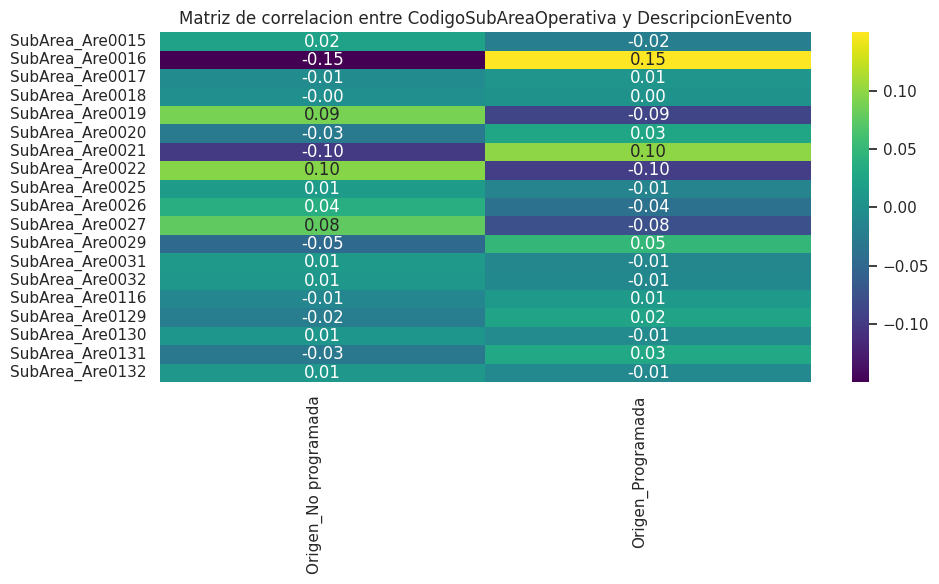

In [21]:
## Matriz de correlacion con respecto a origen Evento
# Creacion de DF
df_corr = data[['CodigoSubAreaOperativa', 'OrigenEvento']]
# Conversion en variables Dummy para colunas con variables categoricas
df_corr_dummy = pd.get_dummies(df_corr,
                               columns=['CodigoSubAreaOperativa', 'OrigenEvento'],
                               prefix=['SubArea', 'Origen'])
# Calculo de matriz de correlacion entre variables convertidas
corr = df_corr_dummy.corr()
# Reordeno para que en el eje X me quede el campo de origen Evento, y en el eje Y el codigo Subarea
subarea_cols = [col for col in corr.columns if col.startswith('SubArea')]
origen_cols = [col for col in corr.columns if col.startswith('Origen')]
corr_selected = corr.loc[subarea_cols, origen_cols]
# Creo el mapa de calor
plt.figure(figsize=(10, 6))  # Adjust figure size if needed
sns.heatmap(corr_selected, cmap="viridis", annot=True, fmt=".2f")  # Uso '.2f' para mostrar dos decimales en grafica
plt.title('Matriz de correlacion entre CodigoSubAreaOperativa y DescripcionEvento')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

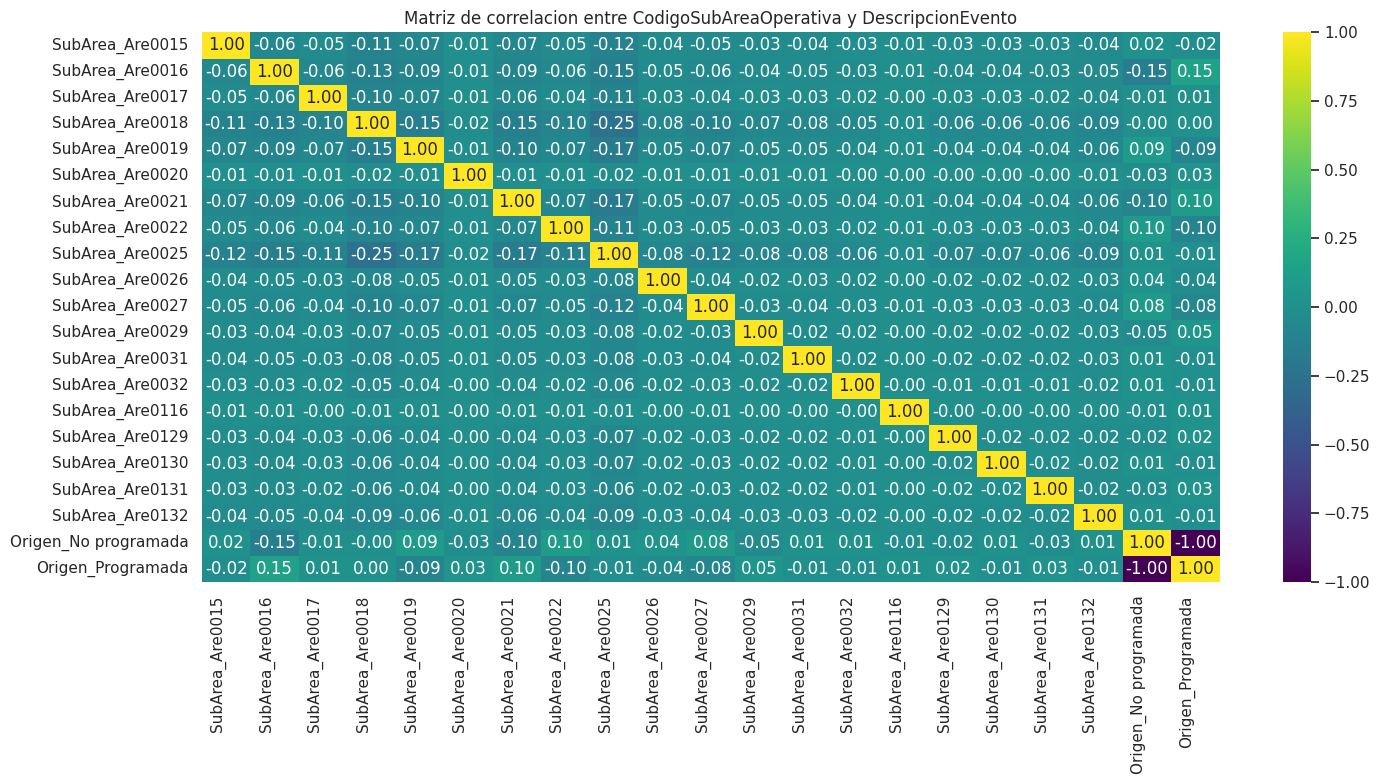

In [22]:
## Matriz de correlacion con respecto a subarea operativa

# Creo el mapa de calor
plt.figure(figsize=(15, 8))  # Adjust figure size if needed
sns.heatmap(corr, cmap="viridis", annot=True, fmt=".2f")  # Uso '.2f' para mostrar dos decimales en grafica
plt.title('Matriz de correlacion entre CodigoSubAreaOperativa y DescripcionEvento')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

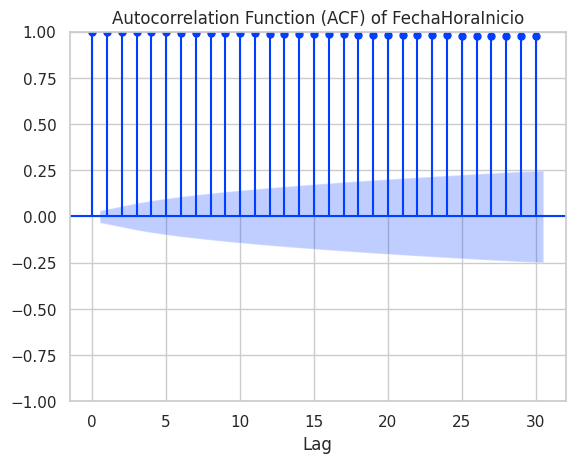

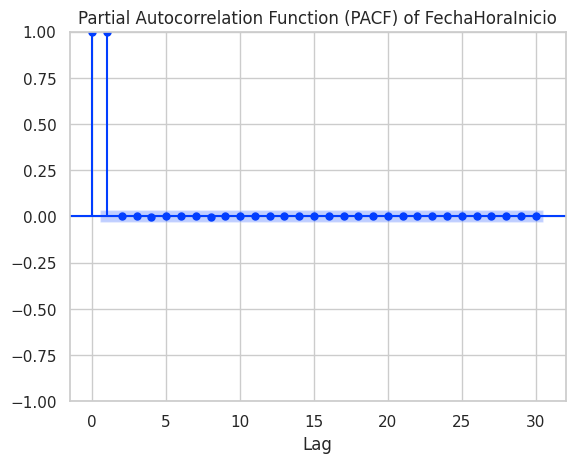

In [24]:
# Convert date columns to datetime objects
data['FechaHoraInicio'] = pd.to_datetime(data['FechaHoraInicio'], errors='coerce')
data['FechaHoraFin'] = pd.to_datetime(data['FechaHoraFin'], errors='coerce')

# Extract a numerical representation of time (e.g., Unix timestamp)
data['FechaHoraInicio_timestamp'] = data['FechaHoraInicio'].astype(np.int64) // 10**9
data['FechaHoraFin_timestamp'] = data['FechaHoraFin'].astype(np.int64) // 10**9

## Autocorrelacion con fecha y hora de inicio del evento
plot_acf(data['FechaHoraInicio_timestamp'].dropna(), lags=30)
plt.xlabel('Lag')
plt.title('Autocorrelation Function (ACF) of FechaHoraInicio')
plt.show()

## Autocorrelacion parcial con fecha y hora de inicio del evento
plot_pacf(data['FechaHoraInicio_timestamp'].dropna(), lags=30)
plt.xlabel('Lag')
plt.title('Partial Autocorrelation Function (PACF) of FechaHoraInicio')
plt.show()

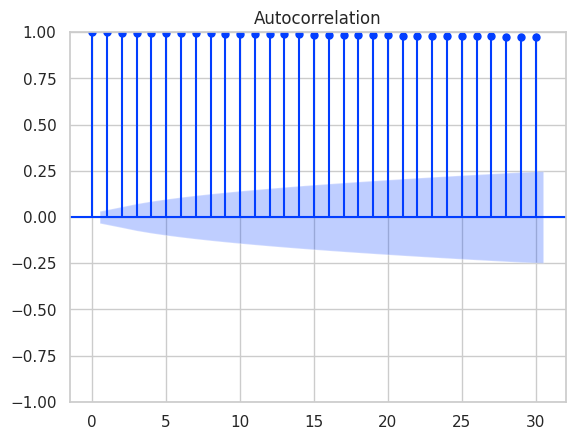

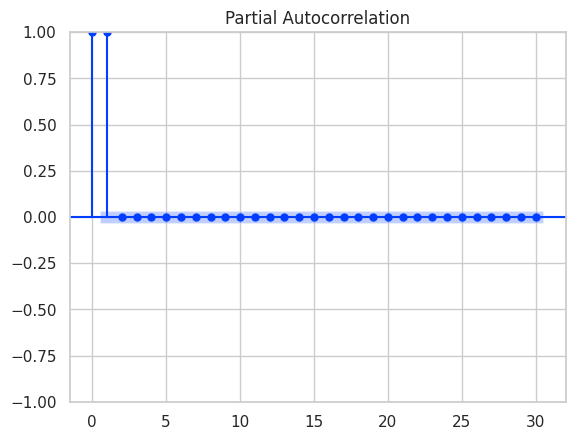

In [25]:
## Autocorrelacion con fecha y hora de fin del evento
plot_acf(data['FechaHoraFin'], lags=30)  # Adjust lags as needed
plt.show()

## Autocorrelacion parcial con fecha y hora de fin del evento
plot_pacf(data['FechaHoraFin'], lags=30)  # Adjust lags as needed
plt.show()

In [26]:
data_origen_desc = data.groupby(['OrigenEvento', 'DescripcionEvento']).size().sort_values(ascending=False)
data_origen_desc

OrigenEvento   DescripcionEvento                                                                                                                                                                                     
No programada  Demanda no atendida por bajas tensiones en la subestación EL BANCO 110 kV.                                                                                                                                33
               Demanda no atendida por disparo del activo GRANADA - OCOA 1 115 kV, dejando sin tensión las S/Es radiales GRANADA 115 kV y SAN JOSE DEL GUAVIARE 115 kV.                                                  21
               Demanda no atendida por disparo del activo EL PASO - EL BANCO 1 110 kV dejando sin tensión la S/E radial EL BANCO 110 kV.                                                                                 19
               Demanda no atendida por disparo del activo FUNDACION - TFUNDACION - RIO CORDOBA 1 110 kV.                                                                                                                 17
               Demanda no atendida por disparo del activo EL PASO - EL COPEY 1 110 kV, dejando sin tensión las S/Es radiales EL PASO 110 kV y EL BANCO 110 kV.                                                           13
                                                                                                                                                                                                                         ..
               Demanda no atendida por disparo del activo BL1 TECHO A TERMINAL 115 kV.                                                                                                                                    1
               Demanda no atendida por disparo del activo BL1 TERMINAL A TECHO 115 KV, dejando sin tensión la S/E radial TECHO 115 kV.                                                                                    1
               Demanda no atendida por disparo del activo BL1 TERMOZIPA A GRAN SABANA 115 kV, dejando sin tensión la subestación radial GRAN SABANA 115 kV.                                                               1
               Demanda no atendida por disparo del activo BL1 TERMOZIPA A SESQUILE 115 kV dejando sin tensión la S/E SESQUILE 115 kV temporalmente radial por condición operativa. El agente reporta falla en el STR.     1
               Demanda no atendida por disparo del activo BL1 SINCE A MAGANGUE 110 kV, dejando sin tensión la S/E radial MAGANGUE 110 kV.                                                                                 1
Length: 2812, dtype: int64

In [27]:
# Crea un diccionario para mapear las categorías a valores numéricos
mapeo_categorias = {categoria: valor for valor, categoria in enumerate(data['DescripcionEvento'].unique())}

# Aplica el mapeo a la columna 'DescripcionEvento'
data['DescripcionEvento_Numerica'] = data['DescripcionEvento'].map(mapeo_categorias)

# Imprime el DataFrame actualizado para verificar los cambios
data

,IdentificadorSuceso,FechaHoraInicio,FechaHoraFin,OrigenEvento,EnergiaNoAtendida,DescripcionEvento,CodigoSubAreaOperativa,FechaHoraInicio_timestamp,FechaHoraFin_timestamp,DescripcionEvento_Numerica
0,S000017905,2020-01-31 13:04:00,2020-01-31 19:59:00,No programada,151140.0,Demanda no atendida por disparo del activo SAN...,Are0025,1580475840,1580500740,0
1,S000017904,2020-01-29 09:43:00,2020-01-29 09:53:00,No programada,4630.0,Demanda no atendida por trabajos en la consign...,Are0029,1580290980,1580291580,1
2,S000017903,2020-01-27 14:24:00,2020-01-27 16:31:00,No programada,14610.0,Demanda no atendida por sobrecarga del activo ...,Are0018,1580135040,1580142660,2
3,S000017901,2020-01-26 07:24:00,2020-01-26 13:15:00,Programada,45100.0,Demanda no atendida por trabajos en la consign...,Are0025,1580023440,1580044500,3
4,S000017902,2020-01-26 05:16:00,2020-01-26 06:34:00,Programada,26650.0,Demanda no atendida por trabajos en la consign...,Are0016,1580015760,1580020440,4
...,...,...,...,...,...,...,...,...,...,...
3585,S000022223,2024-04-03 00:00:00,2024-04-03 14:00:00,No programada,140000.0,Continúa demanda no atendida del evento presen...,Are0032,1712102400,1712152800,2797
3586,S000022222,2024-04-02 19:19:00,2024-04-02 19:23:00,No programada,1350.0,Demanda no atendida por disparo del activo STA...,Are0015,1712085540,1712085780,2798
3587,S000022220,2024-04-01 15:41:00,2024-04-01 15:44:00,No programada,1100.0,Demanda no atendida por disparo del activo BL1...,Are0015,1711986060,1711986240,2799
3588,S000022218,2024-04-01 00:00:00,2024-04-01 00:38:00,No programada,1080.0,Continua demanda no atendida por disparo del a...,Are0019,1711929600,1711931880,2800


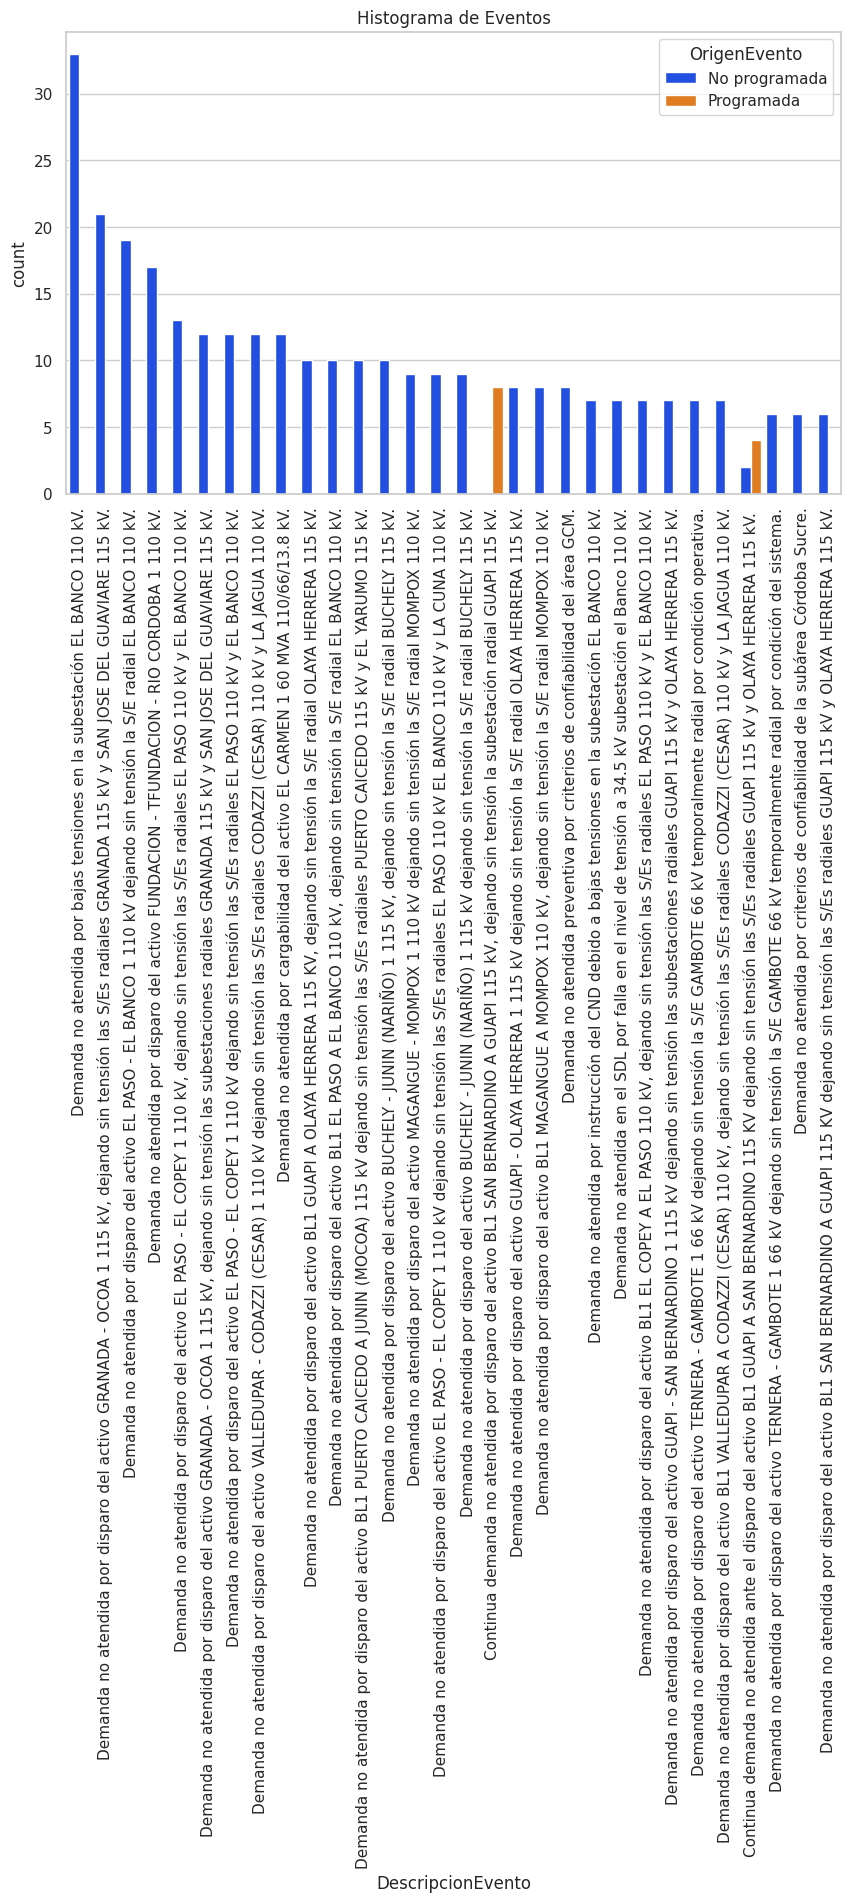

In [28]:
category_counts = data['DescripcionEvento'].value_counts()
category_order = category_counts.index
top_30_categories = category_counts.head(30).index
plt.figure(figsize=(10, 6))  # Ajusta el tamaño de la figura si es necesario
sns.countplot(data=data, x="DescripcionEvento", hue="OrigenEvento", order=top_30_categories)
plt.xticks(rotation=90)  # Rota las etiquetas del eje x para mejor legibilidad
plt.title('Histograma de Eventos')
plt.show()

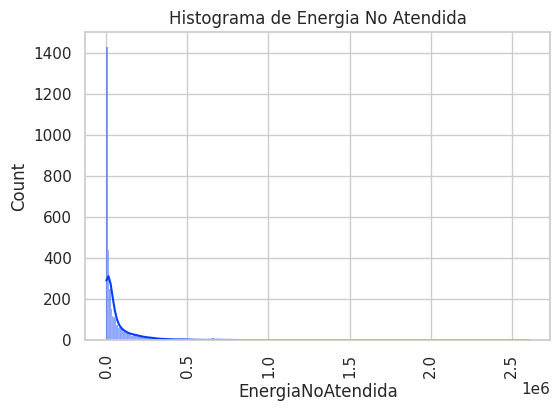

In [29]:
plt.figure(figsize=(6, 4))  # Ajusta el tamaño de la figura si es necesario
sns.histplot(data=data, x="EnergiaNoAtendida", kde=True)
plt.xticks(rotation=90)  # Rota las etiquetas del eje x para mejor legibilidad
plt.title('Histograma de Energia No Atendida')
plt.show()

**Conclusiones**

In [41]:
## Sumatoria de registros
print(f"El total de energia no atendida desde 2020-01-31 hasta 2024-04-30, fue de {data['EnergiaNoAtendida'].sum()} kWh en una duracion de {round(data['DuracionDias'].sum(),4)} dias, correspondiente a {round(data['DuracionHoras'].sum(), 4)} horas")

El total de energia no atendida desde 2020-01-31 hasta 2024-04-30, fue de 230814000.0 kWh en una duracion de 650.7444 dias, correspondiente a 15617.8667 horas


**Analisis de serie de tiempo**

In [38]:
## Analisis temporal de eventos
data['DuracionSegundos'] = (data['FechaHoraFin'] - data['FechaHoraInicio']).dt.total_seconds()
data['DuracionSegundos'].sort_values(ascending=False)

,DuracionSegundos
2475,142260.0
3481,127680.0
2257,111180.0
2943,106200.0
3405,104820.0
...,...
2232,120.0
3535,60.0
1384,0.0
1088,0.0


In [39]:
data['Duracion'] = (data['FechaHoraFin'] - data['FechaHoraInicio'])
data['DuracionHoras'] = data['Duracion'].dt.total_seconds() / 3600
data['DuracionHoras'].sort_values(ascending=False)

,DuracionHoras
2475,39.516667
3481,35.466667
2257,30.883333
2943,29.500000
3405,29.116667
...,...
2232,0.033333
3535,0.016667
1384,0.000000
1088,0.000000


In [40]:
data['Duracion'] = (data['FechaHoraFin'] - data['FechaHoraInicio'])
data['DuracionHoras'] = data['Duracion'].dt.total_seconds() / 3600
data['DuracionDias'] = data['Duracion'].dt.total_seconds() / (3600*24)
data['DuracionDias'].sort_values(ascending=False)

,DuracionDias
2475,1.646528
3481,1.477778
2257,1.286806
2943,1.229167
3405,1.213194
...,...
2232,0.001389
3535,0.000694
1384,0.000000
1088,0.000000


In [33]:
## Estadisticos descriptivos
print(f"La duracion promedio  de los eventos en horas fue de: {round(data['DuracionHoras'].mean(), 5)}")
print(f"La mediana de la duracion de los eventos en horas fue de: {round(data['DuracionHoras'].median(), 5)}")
print(f"La desviacion estandar de los eventos en horas fue de: {round(data['DuracionHoras'].std(), 5)}")

La duracion promedio  de los eventos en horas fue de: 4.35038
La mediana de la duracion de los eventos en horas fue de: 1.65833
La desviacion estandar de los eventos en horas fue de: 5.5016


In [34]:
## Calculo percentiles
print("Percentiles para duracion de eventos en horas")
print(f"El percentil 25% es igual a {data['DuracionHoras'].quantile(q=0.25)}")
print(f"El percentil 50% es igual a {round(data['DuracionHoras'].quantile(q=0.5), 5)}")
print(f"El percentil 75% es igual a {round(data['DuracionHoras'].quantile(q=0.75), 5)}")

Percentiles para duracion de eventos en horas
El percentil 25% es igual a 0.3
El percentil 50% es igual a 1.65833
El percentil 75% es igual a 7.61667


# **Construccion de modelo predictivo**

**Ingenieria de caracteristicas**

In [35]:
X=data.drop(['OrigenEvento'], axis=1)
X

,IdentificadorSuceso,FechaHoraInicio,FechaHoraFin,EnergiaNoAtendida,DescripcionEvento,CodigoSubAreaOperativa,FechaHoraInicio_timestamp,FechaHoraFin_timestamp,DescripcionEvento_Numerica,Duracion,DuracionHoras,DuracionDias
0,S000017905,2020-01-31 13:04:00,2020-01-31 19:59:00,151140.0,Demanda no atendida por disparo del activo SAN...,Are0025,1580475840,1580500740,0,0 days 06:55:00,6.916667,0.288194
1,S000017904,2020-01-29 09:43:00,2020-01-29 09:53:00,4630.0,Demanda no atendida por trabajos en la consign...,Are0029,1580290980,1580291580,1,0 days 00:10:00,0.166667,0.006944
2,S000017903,2020-01-27 14:24:00,2020-01-27 16:31:00,14610.0,Demanda no atendida por sobrecarga del activo ...,Are0018,1580135040,1580142660,2,0 days 02:07:00,2.116667,0.088194
3,S000017901,2020-01-26 07:24:00,2020-01-26 13:15:00,45100.0,Demanda no atendida por trabajos en la consign...,Are0025,1580023440,1580044500,3,0 days 05:51:00,5.850000,0.243750
4,S000017902,2020-01-26 05:16:00,2020-01-26 06:34:00,26650.0,Demanda no atendida por trabajos en la consign...,Are0016,1580015760,1580020440,4,0 days 01:18:00,1.300000,0.054167
...,...,...,...,...,...,...,...,...,...,...,...,...
3585,S000022223,2024-04-03 00:00:00,2024-04-03 14:00:00,140000.0,Continúa demanda no atendida del evento presen...,Are0032,1712102400,1712152800,2797,0 days 14:00:00,14.000000,0.583333
3586,S000022222,2024-04-02 19:19:00,2024-04-02 19:23:00,1350.0,Demanda no atendida por disparo del activo STA...,Are0015,1712085540,1712085780,2798,0 days 00:04:00,0.066667,0.002778
3587,S000022220,2024-04-01 15:41:00,2024-04-01 15:44:00,1100.0,Demanda no atendida por disparo del activo BL1...,Are0015,1711986060,1711986240,2799,0 days 00:03:00,0.050000,0.002083
3588,S000022218,2024-04-01 00:00:00,2024-04-01 00:38:00,1080.0,Continua demanda no atendida por disparo del a...,Are0019,1711929600,1711931880,2800,0 days 00:38:00,0.633333,0.026389


In [36]:
Y=data['OrigenEvento']
Y

,OrigenEvento
0,No programada
1,No programada
2,No programada
3,Programada
4,Programada
...,...
3585,No programada
3586,No programada
3587,No programada
3588,No programada
